In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn nltk -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving flipkart_reviews_dataset.csv to flipkart_reviews_dataset.csv


In [ ]:
df = pd.read_csv('flipkart_reviews_dataset.csv')

df.head()

,review,sentiment
0,The product works perfectly,positive
1,Worth the money,positive
2,Excellent customer service,positive
3,Superb shopping experience,positive
4,Average experience,neutral


In [ ]:
print("Dataset Shape:", df.shape)

print("\nSentiment Counts:")
print(df['sentiment'].value_counts())

Dataset Shape: (300, 2)

Sentiment Counts:
sentiment
positive    150
negative    100
neutral      50
Name: count, dtype: int64


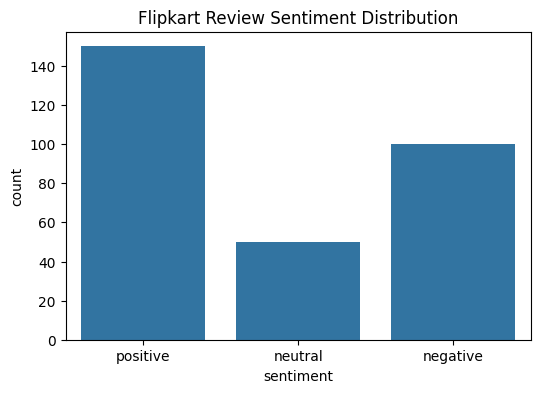

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=df)

plt.title("Flipkart Review Sentiment Distribution")

plt.show()

In [ ]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Remove special characters
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Split words
    text = text.split()

    # Remove stopwords and apply stemming
    text = [stemmer.stem(word) for word in text if word not in stop_words]

    return ' '.join(text)

In [ ]:
df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review,sentiment,clean_review
0,The product works perfectly,positive,product work perfectli
1,Worth the money,positive,worth money
2,Excellent customer service,positive,excel custom servic
3,Superb shopping experience,positive,superb shop experi
4,Average experience,neutral,averag experi


In [ ]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_review'])

y = df['sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        14
     neutral       1.00      1.00      1.00        11
    positive       1.00      1.00      1.00        35

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



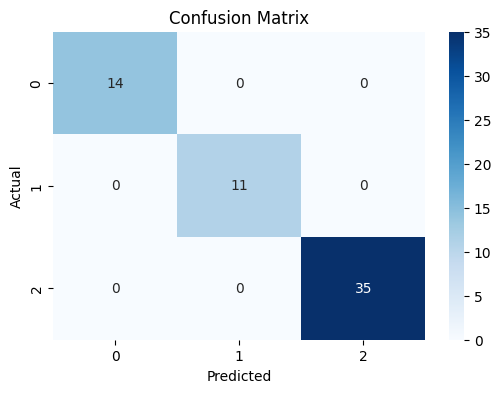

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [ ]:
sample = "This product is amazing and delivery was fast"

# Clean text
sample_clean = clean_text(sample)

# Convert to vector
sample_vector = vectorizer.transform([sample_clean])

# Predict
prediction = model.predict(sample_vector)

print("Review:", sample)

print("Predicted Sentiment:", prediction[0])

Review: This product is amazing and delivery was fast
Predicted Sentiment: positive


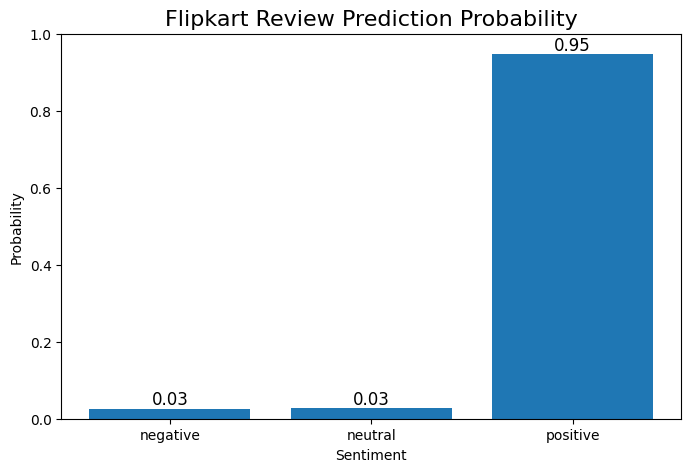

In [ ]:
probabilities = model.predict_proba(sample_vector)[0]


labels = model.classes_


result_df = pd.DataFrame({
    'Sentiment': labels,
    'Probability': probabilities
})


plt.figure(figsize=(8,5))

bars = plt.bar(result_df['Sentiment'],
               result_df['Probability'])

for bar in bars:

    yval = bar.get_height()

    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.01,
             round(yval,2),
             ha='center',
             fontsize=12)

plt.title("Flipkart Review Prediction Probability",
          fontsize=16)

plt.xlabel("Sentiment")

plt.ylabel("Probability")

plt.ylim(0,1)

plt.show()